# Linear Regression, MSE and Gradient Descent — NumPy Lab

**Prepared for Rajni Singh’s AI/ML leadership roadmap**

This notebook accompanies the book-style chapter. Work through it in order and rewrite the core training loop from memory at the end.

## Learning goals

1. Generate predictions with `X @ theta`.
2. Calculate MSE, RMSE, MAE and R².
3. Derive and implement the vectorized gradient.
4. Train simple and multiple linear regression with batch gradient descent.
5. Compare with the pseudoinverse.
6. Diagnose learning-rate and feature-scaling problems.
7. Verify the analytical gradient with finite differences.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)


## 1. Create a simple regression dataset

The example predicts incident-resolution hours from an illustrative feature: number of impacted services. The data are synthetic and contain random noise.


In [2]:
rng = np.random.default_rng(42)
x = np.linspace(0.5, 10.0, 60)
y = 2.75 + 2.35 * x + rng.normal(0, 1.55, size=x.shape)

X = np.column_stack([np.ones_like(x), x])
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (60, 2)
y shape: (60,)


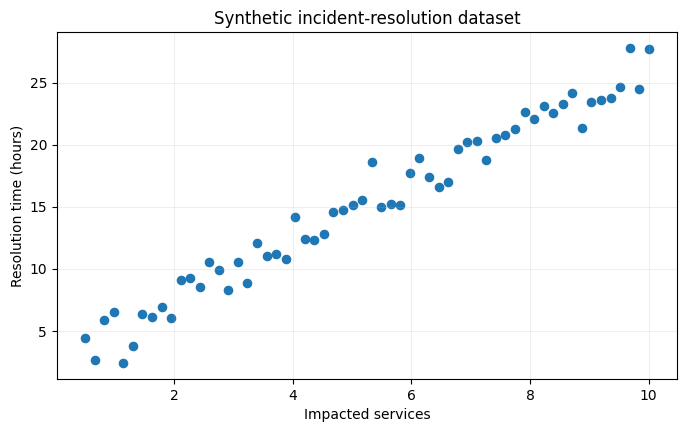

In [3]:
plt.figure(figsize=(8, 4.5))
plt.scatter(x, y, s=35)
plt.xlabel("Impacted services")
plt.ylabel("Resolution time (hours)")
plt.title("Synthetic incident-resolution dataset")
plt.grid(alpha=0.2)
plt.show()


## 2. Model, residual and MSE

\[
\hat y = X	heta, \qquad e = \hat y - y, \qquad
J(	heta)=rac{1}{n}\lVert X	heta-yVert^2
\]


In [4]:
def predict(X: np.ndarray, theta: np.ndarray) -> np.ndarray:
    return X @ theta


def mse(y: np.ndarray, y_hat: np.ndarray) -> float:
    return float(np.mean((y_hat - y) ** 2))


def rmse(y: np.ndarray, y_hat: np.ndarray) -> float:
    return float(np.sqrt(mse(y, y_hat)))


def mae(y: np.ndarray, y_hat: np.ndarray) -> float:
    return float(np.mean(np.abs(y_hat - y)))


def r2(y: np.ndarray, y_hat: np.ndarray) -> float:
    return float(1 - np.sum((y - y_hat) ** 2) / np.sum((y - y.mean()) ** 2))


## 3. Batch gradient descent

The gradient is:

\[

abla J(	heta)=rac{2}{n}X^T(X	heta-y)
\]

The update is:

\[
	heta \leftarrow 	heta - lpha 
abla J(	heta)
\]


In [5]:
def fit_linear_regression_gd(
    X: np.ndarray,
    y: np.ndarray,
    learning_rate: float = 0.012,
    steps: int = 1800,
    theta0: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    if X.ndim != 2 or len(X) != len(y):
        raise ValueError("X must be 2-D and align with y")
    if not np.isfinite(X).all() or not np.isfinite(y).all():
        raise ValueError("X and y must contain finite values")

    theta = np.zeros(X.shape[1]) if theta0 is None else theta0.astype(float).copy()
    history = np.empty(steps)
    n = len(y)

    for step in range(steps):
        y_hat = X @ theta
        error = y_hat - y
        gradient = (2.0 / n) * (X.T @ error)
        theta -= learning_rate * gradient
        history[step] = np.mean(error ** 2)

    return theta, history


In [6]:
theta, history = fit_linear_regression_gd(X, y)
y_hat = predict(X, theta)

theta_closed = np.linalg.pinv(X) @ y

print("Gradient descent theta:", theta)
print("Pseudoinverse theta:    ", theta_closed)
print(f"MSE:  {mse(y, y_hat):.4f}")
print(f"RMSE: {rmse(y, y_hat):.4f}")
print(f"MAE:  {mae(y, y_hat):.4f}")
print(f"R2:   {r2(y, y_hat):.4f}")


Gradient descent theta: [2.6757 2.3834]
Pseudoinverse theta:     [2.6759 2.3834]
MSE:  1.4495
RMSE: 1.2040
MAE:  0.9871
R2:   0.9682


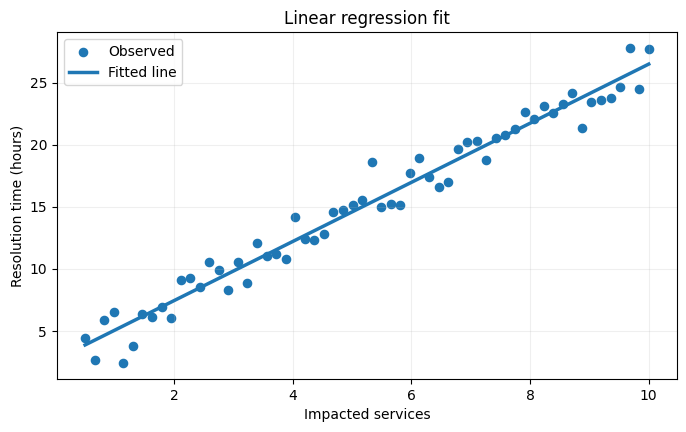

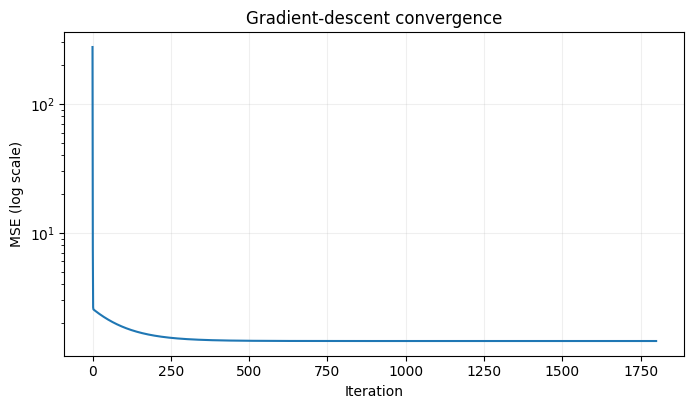

In [7]:
plt.figure(figsize=(8, 4.5))
plt.scatter(x, y, s=35, label="Observed")
plt.plot(x, y_hat, linewidth=2.5, label="Fitted line")
plt.xlabel("Impacted services")
plt.ylabel("Resolution time (hours)")
plt.title("Linear regression fit")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4.2))
plt.plot(history)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("MSE (log scale)")
plt.title("Gradient-descent convergence")
plt.grid(alpha=0.2)
plt.show()


## 4. Manual first update

Use three observations and confirm the first gradient-descent update by hand before running the cell.


In [8]:
x_small = np.array([1.0, 2.0, 3.0])
y_small = np.array([2.0, 4.0, 5.0])
w, b, alpha = 0.0, 0.0, 0.05

pred = w * x_small + b
error = pred - y_small
loss = np.mean(error ** 2)
dw = (2 / len(y_small)) * np.sum(error * x_small)
db = (2 / len(y_small)) * np.sum(error)

w_new = w - alpha * dw
b_new = b - alpha * db
new_loss = np.mean((w_new * x_small + b_new - y_small) ** 2)

print("initial loss:", loss)
print("dw, db:", dw, db)
print("new w, b:", w_new, b_new)
print("new loss:", new_loss)


initial loss: 15.0
dw, db: -16.666666666666664 -7.333333333333333
new w, b: 0.8333333333333333 0.3666666666666667
new loss: 3.0196296296296303


## 5. Learning-rate experiment

Run several learning rates. Explain why each curve behaves as it does.


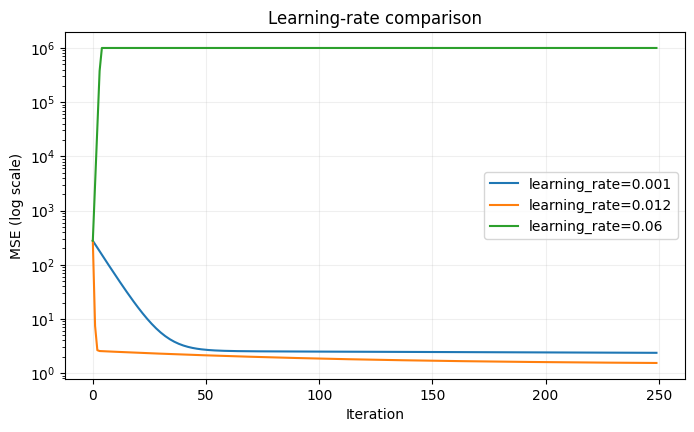

In [9]:
plt.figure(figsize=(8, 4.5))
for lr in [0.001, 0.012, 0.06]:
    _, h = fit_linear_regression_gd(X, y, learning_rate=lr, steps=250)
    h = np.minimum(h, 1e6)
    plt.plot(h, label=f"learning_rate={lr}")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("MSE (log scale)")
plt.title("Learning-rate comparison")
plt.grid(alpha=0.2)
plt.legend()
plt.show()


## 6. Finite-difference gradient check

A numerical gradient is slower but useful for testing an analytical gradient implementation.


In [10]:
def analytical_gradient(X, y, theta):
    return (2.0 / len(y)) * X.T @ (X @ theta - y)


def numerical_gradient(X, y, theta, epsilon=1e-6):
    grad = np.zeros_like(theta)
    for j in range(len(theta)):
        step = np.zeros_like(theta)
        step[j] = epsilon
        plus = mse(y, X @ (theta + step))
        minus = mse(y, X @ (theta - step))
        grad[j] = (plus - minus) / (2 * epsilon)
    return grad


theta_test = np.array([0.3, -0.2])
g1 = analytical_gradient(X, y, theta_test)
g2 = numerical_gradient(X, y, theta_test)
print("analytical:", g1)
print("numerical: ", g2)
print("maximum absolute difference:", np.max(np.abs(g1 - g2)))


analytical: [ -31.8774 -207.532 ]
numerical:  [ -31.8774 -207.532 ]
maximum absolute difference: 3.1858803595241625e-08


## 7. Multiple regression with feature scaling

We generate an enterprise-style dataset with severity, impacted services, backlog and an automation flag. We use a temporal holdout to mimic deployment into the future.


In [11]:
rng = np.random.default_rng(123)
n = 400
month_index = np.arange(n)
severity = rng.integers(1, 5, n)
impacted = rng.integers(1, 25, n)
backlog = np.maximum(0, rng.normal(28 + 0.03 * month_index, 10, n))
automation = rng.integers(0, 2, n)
noise = rng.normal(0, 2.2, n)

y_hours = (
    1.5
    + 1.8 * severity
    + 0.32 * impacted
    + 0.075 * backlog
    - 2.1 * automation
    + noise
)

X_raw = np.column_stack([severity, impacted, backlog, automation])
split = 320
X_train_raw, X_test_raw = X_raw[:split], X_raw[split:]
y_train, y_test = y_hours[:split], y_hours[split:]

mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)
sigma = np.where(sigma == 0, 1.0, sigma)
X_train_scaled = (X_train_raw - mu) / sigma
X_test_scaled = (X_test_raw - mu) / sigma

X_train = np.column_stack([np.ones(len(X_train_scaled)), X_train_scaled])
X_test = np.column_stack([np.ones(len(X_test_scaled)), X_test_scaled])

theta_multi, hist_multi = fit_linear_regression_gd(
    X_train, y_train, learning_rate=0.03, steps=2500
)
pred_test = X_test @ theta_multi

print("theta on standardized features:", theta_multi)
print(f"test RMSE: {rmse(y_test, pred_test):.3f}")
print(f"test MAE:  {mae(y_test, pred_test):.3f}")
print(f"test R2:   {r2(y_test, pred_test):.3f}")


theta on standardized features: [10.9739  1.8064  2.3163  0.6348 -1.1387]
test RMSE: 2.359
test MAE:  1.838
test R2:   0.668


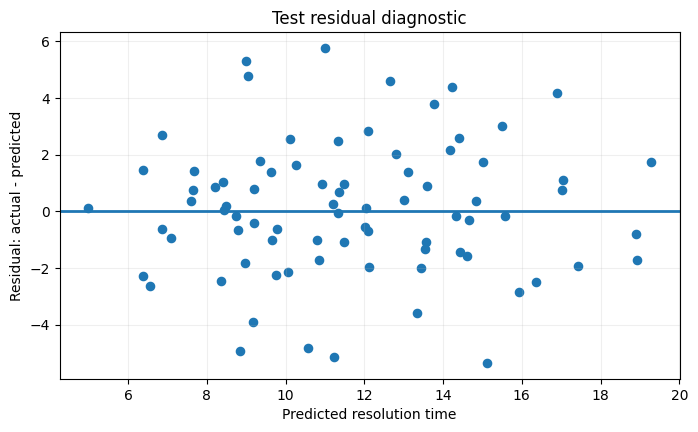

severity 1: n=22, MAE=1.838
severity 2: n=14, MAE=1.279
severity 3: n=16, MAE=2.474
severity 4: n=28, MAE=1.753


In [12]:
residual = y_test - pred_test
plt.figure(figsize=(8, 4.5))
plt.scatter(pred_test, residual, s=35)
plt.axhline(0, linewidth=2)
plt.xlabel("Predicted resolution time")
plt.ylabel("Residual: actual - predicted")
plt.title("Test residual diagnostic")
plt.grid(alpha=0.2)
plt.show()

for s in sorted(np.unique(severity[split:])):
    mask = severity[split:] == s
    print(
        f"severity {s}: n={mask.sum():2d}, "
        f"MAE={mae(y_test[mask], pred_test[mask]):.3f}"
    )


## 8. Exercises

1. Rewrite `fit_linear_regression_gd` without looking.
2. Add early stopping using a tolerance and patience counter.
3. Add Ridge regularization while excluding the intercept from the penalty.
4. Add an irrelevant random feature and inspect its coefficient.
5. Compare random and temporal splits. Explain which is realistic and why.
6. Change the target so underprediction costs twice as much as overprediction. Propose a more suitable objective or model.
7. Prepare a five-minute production design for incident-resolution prediction, including leakage controls, rollout and monitoring.


## 9. Completion check

You are ready to move on when you can:

- derive the two simple-regression gradients;
- write the vectorized update from memory;
- explain MSE versus MAE using business cost;
- diagnose a bad learning-rate curve;
- identify future-data leakage in an incident example;
- explain why the linear baseline matters even when a complex model performs better.
